In [1]:
!pip install -q transformers datasets peft accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 17.3 MB/s eta 0:00:00


In [2]:
from google.colab import files
uploaded = files.upload()

Saving train_formatted.json to train_formatted.json


In [3]:
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, Trainer, TrainingArguments
from peft import LoraConfig, get_peft_model, TaskType

MODEL_ID = "google/flan-t5-base"

# Load dataset
dataset = load_dataset("json", data_files="train_formatted.json")

# Load tokenizer + model
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_ID)

# Tokenize
def preprocess(example):
    inputs = tokenizer(example["input"], truncation=True, padding="max_length", max_length=512)
    outputs = tokenizer(example["output"], truncation=True, padding="max_length", max_length=128)

    inputs["labels"] = outputs["input_ids"]
    return inputs

dataset = dataset.map(preprocess)

# LoRA config
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q", "v"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.SEQ_2_SEQ_LM
)

model = get_peft_model(model, lora_config)

# Training args
training_args = TrainingArguments(
    output_dir="policypal-qlora",
    per_device_train_batch_size=2,
    num_train_epochs=3,
    logging_steps=10,
    save_strategy="epoch",
    learning_rate=2e-4,
    fp16=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
)

# Train
trainer.train()

# Save model
model.save_pretrained("policypal-qlora/final")
tokenizer.save_pretrained("policypal-qlora/final")

print("Training complete!")

Generating train split: 0 examples [00:00, ? examples/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

...

Map:   0%|          | 0/335 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
10,10.832966
20,10.871574
30,10.826651
40,10.798712
50,10.753368
60,10.508385
70,10.397894
80,10.186150
90,10.067324
100,9.961334


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training complete!


In [4]:
!zip -r adapter.zip policypal-qlora/final
from google.colab import files
files.download("adapter.zip")

  adding: policypal-qlora/final/ (stored 0%)
  adding: policypal-qlora/final/adapter_config.json (deflated 57%)
  adding: policypal-qlora/final/adapter_model.safetensors (deflated 7%)
  adding: policypal-qlora/final/README.md (deflated 66%)
  adding: policypal-qlora/final/tokenizer_config.json (deflated 83%)
  adding: policypal-qlora/final/tokenizer.json (deflated 79%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

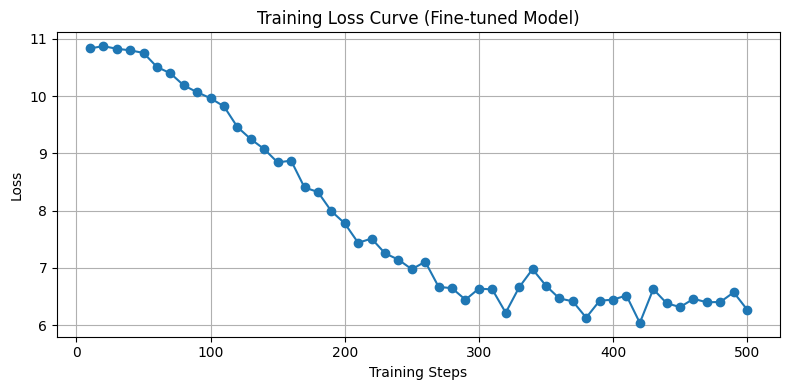

In [3]:
from pathlib import Path
import matplotlib.pyplot as plt

# ✅ ensure correct results path
RESULTS_DIR = Path('../results')   # adjust if needed
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Your data
steps = [
10,20,30,40,50,60,70,80,90,100,
110,120,130,140,150,160,170,180,190,200,
210,220,230,240,250,260,270,280,290,300,
310,320,330,340,350,360,370,380,390,400,
410,420,430,440,450,460,470,480,490,500
]

loss = [
10.832966,10.871574,10.826651,10.798712,10.753368,10.508385,10.397894,10.186150,10.067324,9.961334,
9.819198,9.458425,9.247461,9.072961,8.841087,8.872691,8.403519,8.324768,7.990358,7.776640,
7.437555,7.511153,7.254069,7.142937,6.975397,7.107029,6.667786,6.644292,6.443195,6.637669,
6.622762,6.216888,6.658696,6.977016,6.688082,6.465590,6.415503,6.129425,6.424918,6.444868,
6.516695,6.038583,6.627960,6.381634,6.314436,6.458868,6.398389,6.403771,6.571760,6.270102
]

# Plot
plt.figure(figsize=(8, 4))
plt.plot(steps, loss, marker='o')

plt.title('Training Loss Curve (Fine-tuned Model)')
plt.xlabel('Training Steps')
plt.ylabel('Loss')

plt.grid(True)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_loss.png', dpi=150)
plt.show()

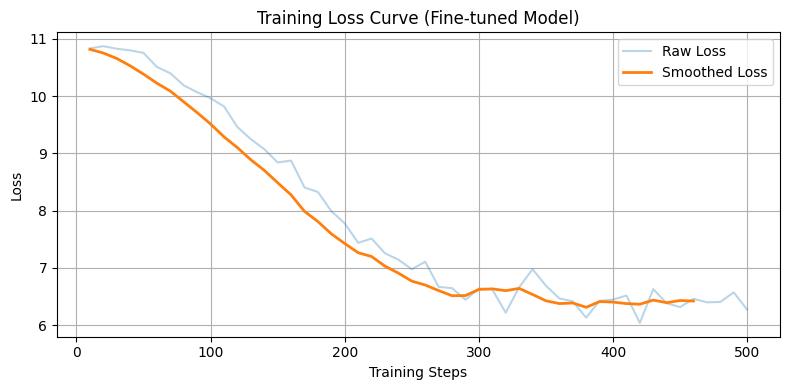

In [4]:
import numpy as np

smooth_loss = np.convolve(loss, np.ones(5)/5, mode='valid')

plt.figure(figsize=(8, 4))
plt.plot(steps, loss, alpha=0.3, label='Raw Loss')
plt.plot(steps[:len(smooth_loss)], smooth_loss, linewidth=2, label='Smoothed Loss')

plt.title('Training Loss Curve (Fine-tuned Model)')
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()